## Loading Data and EDA

In [153]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [154]:
df= pd.read_csv('/content/Student-Employability.csv')
df.shape

(2982, 10)

In [155]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2982 entries, 0 to 2981
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Name of Student             2982 non-null   object
 1   GENERAL APPEARANCE          2982 non-null   int64 
 2   MANNER OF SPEAKING          2982 non-null   int64 
 3   PHYSICAL CONDITION          2982 non-null   int64 
 4   MENTAL ALERTNESS            2982 non-null   int64 
 5   SELF-CONFIDENCE             2982 non-null   int64 
 6   ABILITY TO PRESENT IDEAS    2982 non-null   int64 
 7   COMMUNICATION SKILLS        2982 non-null   int64 
 8   Student Performance Rating  2982 non-null   int64 
 9   CLASS                       2982 non-null   object
dtypes: int64(8), object(2)
memory usage: 233.1+ KB


In [156]:
df.drop('Name of Student', axis=1, inplace =True)

In [157]:
df['CLASS'] = df['CLASS'].map({'Employable': 1, 'LessEmployable': 0})

In [158]:
df.rename(columns= {'SELF-CONFIDENCE': 'SELF CONFIDENCE',
                    'Student Performance Rating': 'STUDENT PERFORMANCE RATING'}, inplace= True)

In [159]:
df.head()

,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,STUDENT PERFORMANCE RATING,CLASS
0,4,5,4,5,5,5,5,5,1
1,4,4,4,4,4,4,3,5,1
2,4,3,3,3,3,3,2,5,0
3,3,3,3,2,3,3,3,5,0
4,4,4,3,3,4,4,3,5,1


## Association between Features(X) and Target(Y)

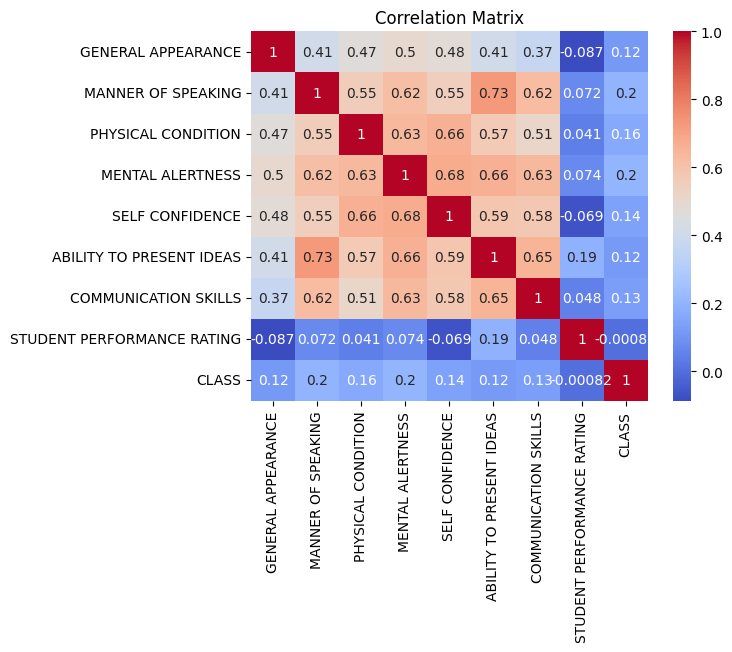

In [160]:
plt.figure()
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

## Segregating the Features(X) and Target(Y)

In [161]:
X = df.drop('CLASS', axis=1)
Y = df['CLASS']

In [162]:
X

,GENERAL APPEARANCE,MANNER OF SPEAKING,PHYSICAL CONDITION,MENTAL ALERTNESS,SELF CONFIDENCE,ABILITY TO PRESENT IDEAS,COMMUNICATION SKILLS,STUDENT PERFORMANCE RATING
0,4,5,4,5,5,5,5,5
1,4,4,4,4,4,4,3,5
2,4,3,3,3,3,3,2,5
3,3,3,3,2,3,3,3,5
4,4,4,3,3,4,4,3,5
...,...,...,...,...,...,...,...,...
2977,4,3,3,3,3,3,2,5
2978,3,4,4,4,4,4,4,5
2979,4,5,4,5,4,4,4,5
2980,4,4,4,3,4,4,3,5


In [163]:
Y

,CLASS
0,1
1,1
2,0
3,0
4,1
...,...
2977,1
2978,1
2979,1
2980,0


In [164]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
Y = le.fit_transform(Y)
Y

array([1, 1, 0, ..., 1, 0, 1])

In [165]:
pd.DataFrame(Y).value_counts()

,count
0,
1,1729
0,1253


## Splitting data into Train and Test

In [166]:
from sklearn.model_selection import train_test_split

In [167]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.25, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((2236, 8), (746, 8), (2236,), (746,))

## Train Data Preprocessing

In [168]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Building Pipeline for Each Model

In [170]:
from sklearn.ensemble import RandomForestClassifier

In [171]:
rf_pipeline = Pipeline([
    ('Scalling', StandardScaler()),
    ('model', RandomForestClassifier(n_estimators= 300, random_state=42, max_depth= 10))
])

### Hyperparameter Tuning

In [172]:
from sklearn.model_selection import GridSearchCV
n_estimators = [100, 200, 300]
max_depth = [10, 20, 30]
param_grid = {'model__n_estimators': n_estimators, 'model__max_depth': max_depth}

grid_search = GridSearchCV(rf_pipeline, param_grid, cv=5, scoring='f1')
grid_search.fit(x_train, y_train)
grid_search.best_params_

{'model__max_depth': 10, 'model__n_estimators': 300}

In [173]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline([
    ('Scalling', StandardScaler()),
    ('model', XGBClassifier(n_estimators= 200, max_depth= 10))
])

### Hyperparameter Tuning

In [174]:
from sklearn.model_selection import GridSearchCV
n_estimators = [100, 200, 300]
max_depth = [10, 20, 30]
param_grid = {'model__n_estimators': n_estimators, 'model__max_depth': max_depth}

grid_search = GridSearchCV(xgb_pipeline, param_grid, cv=5, scoring='f1')
grid_search.fit(x_train, y_train)
grid_search.best_params_

{'model__max_depth': 10, 'model__n_estimators': 200}

## Model Training

In [175]:
rf_pipeline.fit(x_train, y_train)

Pipeline(steps=[('Scalling', StandardScaler()),
                ('model',
                 RandomForestClassifier(max_depth=10, n_estimators=300,
                                        random_state=42))])

In [176]:
xgb_pipeline.fit(x_train, y_train)

Pipeline(steps=[('Scalling', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=10, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

## Model Evaluation

In [177]:
from sklearn.metrics import f1_score, classification_report, confusion_matrix

In [178]:
rf_pred= rf_pipeline.predict(x_test)
xgb_pred= xgb_pipeline.predict(x_test)

In [179]:
print('Random Forest Classifier Model Performance: ')
print(f'F1-Score: {f1_score(y_test, rf_pred)}')
print(classification_report(y_test, rf_pred))
print('Confusion Matrix: ')
print(confusion_matrix(y_test, rf_pred))

Random Forest Classifier Model Performance: 
F1-Score: 0.89920724801812
              precision    recall  f1-score   support

           0       0.96      0.77      0.85       337
           1       0.84      0.97      0.90       409

    accuracy                           0.88       746
   macro avg       0.90      0.87      0.88       746
weighted avg       0.89      0.88      0.88       746

Confusion Matrix: 
[[260  77]
 [ 12 397]]


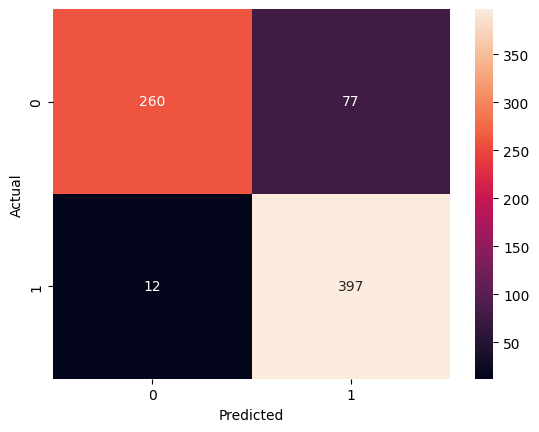

In [180]:
cm= confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [181]:
print('XGBoost Classifier Model Performance: ')
print(f'F1-Score: {f1_score(y_test, xgb_pred)}')
print(classification_report(y_test, xgb_pred))
print('Confusion Matrix: ')
print(confusion_matrix(y_test, xgb_pred))

XGBoost Classifier Model Performance: 
F1-Score: 0.9101941747572816
              precision    recall  f1-score   support

           0       0.90      0.88      0.89       337
           1       0.90      0.92      0.91       409

    accuracy                           0.90       746
   macro avg       0.90      0.90      0.90       746
weighted avg       0.90      0.90      0.90       746

Confusion Matrix: 
[[297  40]
 [ 34 375]]


## Feature Importances

COMMUNICATION SKILLS          10.520958
PHYSICAL CONDITION            11.251619
GENERAL APPEARANCE            11.696076
STUDENT PERFORMANCE RATING    11.746418
ABILITY TO PRESENT IDEAS      12.068966
MANNER OF SPEAKING            12.868290
SELF CONFIDENCE               13.295304
MENTAL ALERTNESS              16.552369
dtype: float64


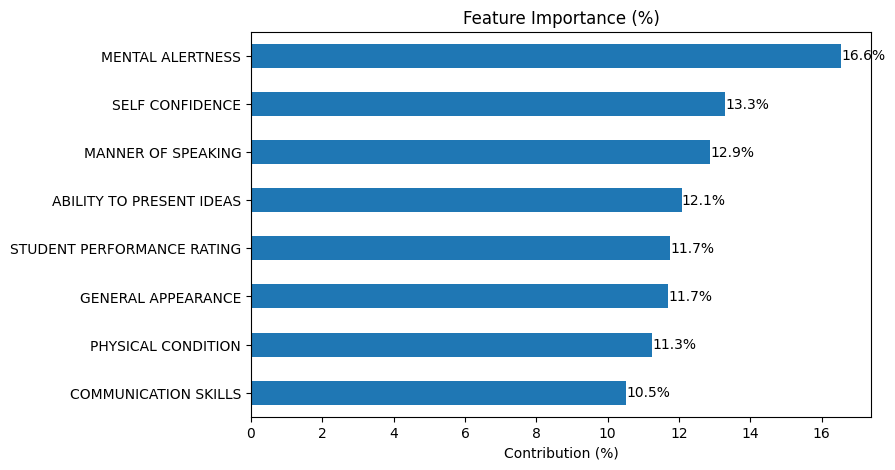

In [182]:
model = rf_pipeline.named_steps['model']
features = pd.Series(model.feature_importances_, index=X.columns)
features = 100 * features / features.sum()
features = features.sort_values()
print(features)

ax = features.plot(kind='barh', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel("Contribution (%)")
plt.title("Feature Importance (%)")
plt.show()

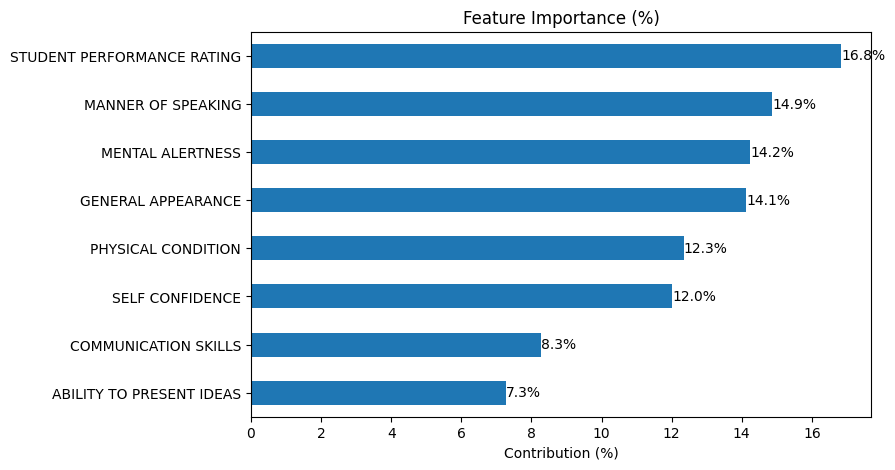

In [183]:
model = xgb_pipeline.named_steps['model']
features = pd.Series(model.feature_importances_, index=X.columns)
features = 100 * features / features.sum()
features = features.sort_values()

ax = features.plot(kind='barh', figsize=(8,5))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%')

plt.xlabel("Contribution (%)")
plt.title("Feature Importance (%)")
plt.show()

In [184]:
best_pipeline= grid_search.best_estimator_
best_pipeline

Pipeline(steps=[('Scalling', StandardScaler()),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=False, eval_metric=None,
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=10, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [185]:
import joblib

In [186]:
joblib.dump(best_pipeline, 'student_employability_model.pkl')

['student_employability_model.pkl']